# PCA Comparison: Netbios vs Portmap
This notebook compares Netbios and Portmap labels from df_dropped_3000 using PCA dimensionality reduction to 2 dimensions.

## Section 1: Import Required Libraries

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

## Section 2: Load and Prepare Data

In [66]:
# Load the data
df_dropped = pd.read_csv('CIC_dfdropped/03-11/df_dropped_3000.csv')

# Display information about the dataset
print("Dataset shape:", df_dropped.shape)
print("\nFirst few rows:")
print(df_dropped.head())
print("\nColumn names:")
print(df_dropped.columns.tolist())
print("\nData types:")
print(df_dropped.dtypes)
print("\nLabel distribution:")
print(df_dropped['Label'].value_counts())

Dataset shape: (35588, 79)

First few rows:
   Flow Duration  Total Fwd Packets  Total Backward Packets  \
0              1                  2                       0   
1              1                  2                       0   
2              1                  2                       0   
3              1                  2                       0   
4              1                  2                       0   

   Total Length of Fwd Packets  Total Length of Bwd Packets  \
0                        494.0                          0.0   
1                        458.0                          0.0   
2                        458.0                          0.0   
3                        458.0                          0.0   
4                        458.0                          0.0   

   Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  \
0                  247.0                  247.0                   247.0   
1                  229.0                  229.0 

## Section 3: Filter Data for Selected Labels

## Section 2.5: Select Labels to Compare

In [107]:
# Specify which labels you want to compare
# You can modify these values to compare any two attack types
labels_to_compare = ['MSSQL', 'UDP', 'Portmap']

# Display all available labels for reference
print("Available labels in the dataset:")
print(df_dropped['Label'].unique())
print("\n" + "="*60)
print(f"Currently comparing: {labels_to_compare}")
print("="*60)

Available labels in the dataset:
['Portmap' 'BENIGN' 'LDAP' 'NetBIOS' 'MSSQL' 'UDP' 'Syn' 'UDPLag']

Currently comparing: ['MSSQL', 'UDP', 'Portmap']


In [108]:
# Filter data for selected labels
df_filtered = df_dropped[df_dropped['Label'].isin(labels_to_compare)].copy()

# Check which labels are actually present
print("Available labels in filtered data:")
print(df_filtered['Label'].value_counts())
print(f"\nFiltered dataset shape: {df_filtered.shape}")

# Identify the feature columns (exclude Label and task_id if present)
feature_cols = [col for col in df_filtered.columns if col not in ['Label', 'task_id']]
print(f"\nNumber of features: {len(feature_cols)}")

# Prepare feature matrix and labels
X = df_filtered[feature_cols].values
y = df_filtered['Label'].values

# Check for missing values
missing_count = np.sum(np.isnan(X))
print(f"Missing values in features: {missing_count}")

# Handle any missing values by dropping rows
X = np.nan_to_num(X, nan=0.0)
print(f"\nFinal data shape for PCA: {X.shape}")
print(f"Final labels shape: {y.shape}")

Available labels in filtered data:
Label
UDP        3447
Portmap    3000
MSSQL      2803
Name: count, dtype: int64

Filtered dataset shape: (9250, 79)

Number of features: 77
Missing values in features: 0

Final data shape for PCA: (9250, 77)
Final labels shape: (9250,)


## Section 4: Apply PCA Dimensionality Reduction

In [109]:
# Standardize the features (important for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Display PCA information
print("PCA Model Information:")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Cumulative explained variance: {np.sum(pca.explained_variance_ratio_):.4f}")
print(f"PC1 explains: {pca.explained_variance_ratio_[0]:.4f} of variance")
print(f"PC2 explains: {pca.explained_variance_ratio_[1]:.4f} of variance")
print(f"\nTransformed data shape: {X_pca.shape}")


PCA Model Information:
Explained variance ratio: [0.2219888  0.19346686]
Cumulative explained variance: 0.4155
PC1 explains: 0.2220 of variance
PC2 explains: 0.1935 of variance

Transformed data shape: (9250, 2)


## Section 5: Visualize PCA Results

In [110]:

# Outlier Detection and Removal using Isolation Forest
from sklearn.ensemble import IsolationForest

# Detect outliers using Isolation Forest on the 3D PCA data
iso_forest = IsolationForest(contamination=0.05, random_state=42)  # Remove top 5% outliers
outlier_predictions = iso_forest.fit_predict(X_pca)

# Get the indices of inliers (non-outliers)
inlier_indices = np.where(outlier_predictions == 1)[0]
outlier_indices = np.where(outlier_predictions == -1)[0]

print(f"Total points: {len(X_pca)}")
print(f"Outliers detected: {len(outlier_indices)}")
print(f"Inliers retained: {len(inlier_indices)}")
print(f"Percentage of data retained: {len(inlier_indices)/len(X_pca)*100:.2f}%\n")

# Filter data to remove outliers
X_pca_clean = X_pca[inlier_indices]
y_clean = y[inlier_indices]

print("PCA data after outlier removal:")
print(f"Shape: {X_pca_clean.shape}")
print(f"Labels distribution:\n{pd.Series(y_clean).value_counts()}")


Total points: 9250
Outliers detected: 463
Inliers retained: 8787
Percentage of data retained: 94.99%

PCA data after outlier removal:
Shape: (8787, 2)
Labels distribution:
UDP        3250
Portmap    2990
MSSQL      2547
Name: count, dtype: int64


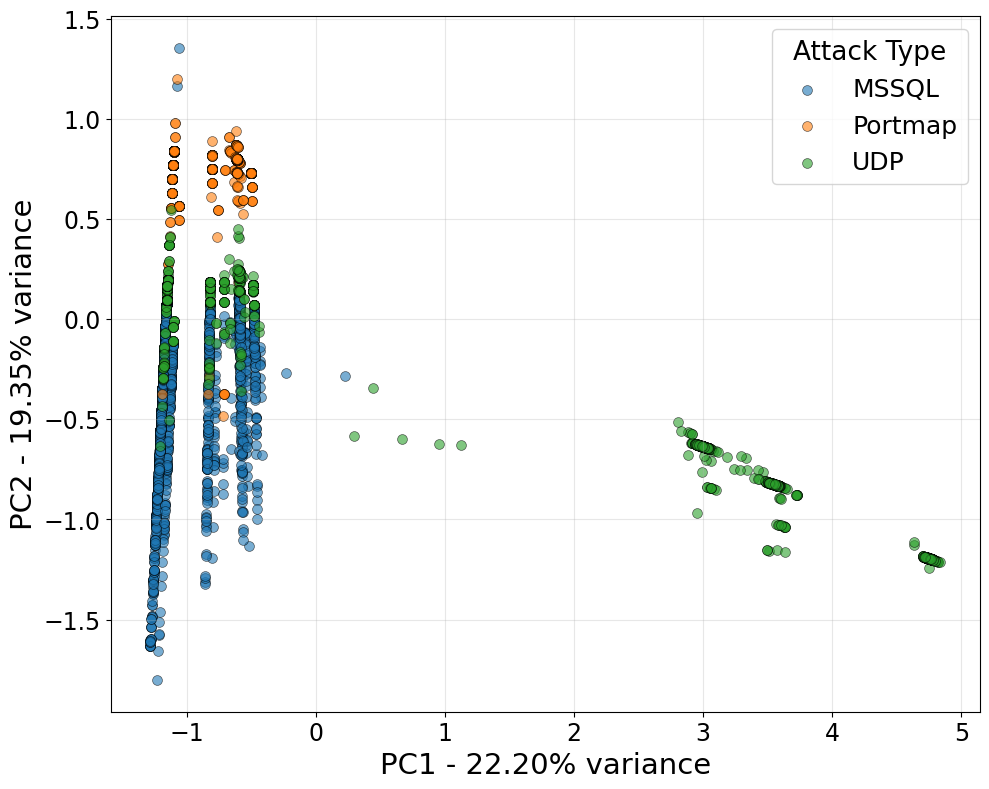

Total variance explained by 2 components: 41.55%


In [111]:
# Create a 2D scatter plot of PCA results (without outliers)
fig, ax = plt.subplots(figsize=(10, 8))

labels_unique = np.unique(y_clean)

# Plot each label with a different color
for label in labels_unique:
    mask = y_clean == label
    ax.scatter(X_pca_clean[mask, 0], X_pca_clean[mask, 1],
               label=label, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

ax.set_xlabel(f'PC1 - {pca.explained_variance_ratio_[0]:.2%} variance', fontsize=21)
ax.set_ylabel(f'PC2 - {pca.explained_variance_ratio_[1]:.2%} variance', fontsize=21)
#ax.set_title(f'2D PCA Visualization: {" vs ".join(labels_to_compare)}', fontsize=14, fontweight='bold')
ax.legend(title='Attack Type', fontsize=18, title_fontsize=19)
ax.grid(True, alpha=0.3)
plt.xticks(fontsize=17)
plt.yticks(fontsize=17)
plt.tight_layout()
plt.savefig(f"./Result_Collection/thesis_PCA/PCA_{labels_to_compare[0]}_{labels_to_compare[1]}_{labels_to_compare[2]}.pdf", bbox_inches='tight')
plt.show()

print(f"Total variance explained by 2 components: {np.sum(pca.explained_variance_ratio_):.2%}")


## Section 6: Compare Label Distributions

## Section 7: Plot All Labels in One Graph

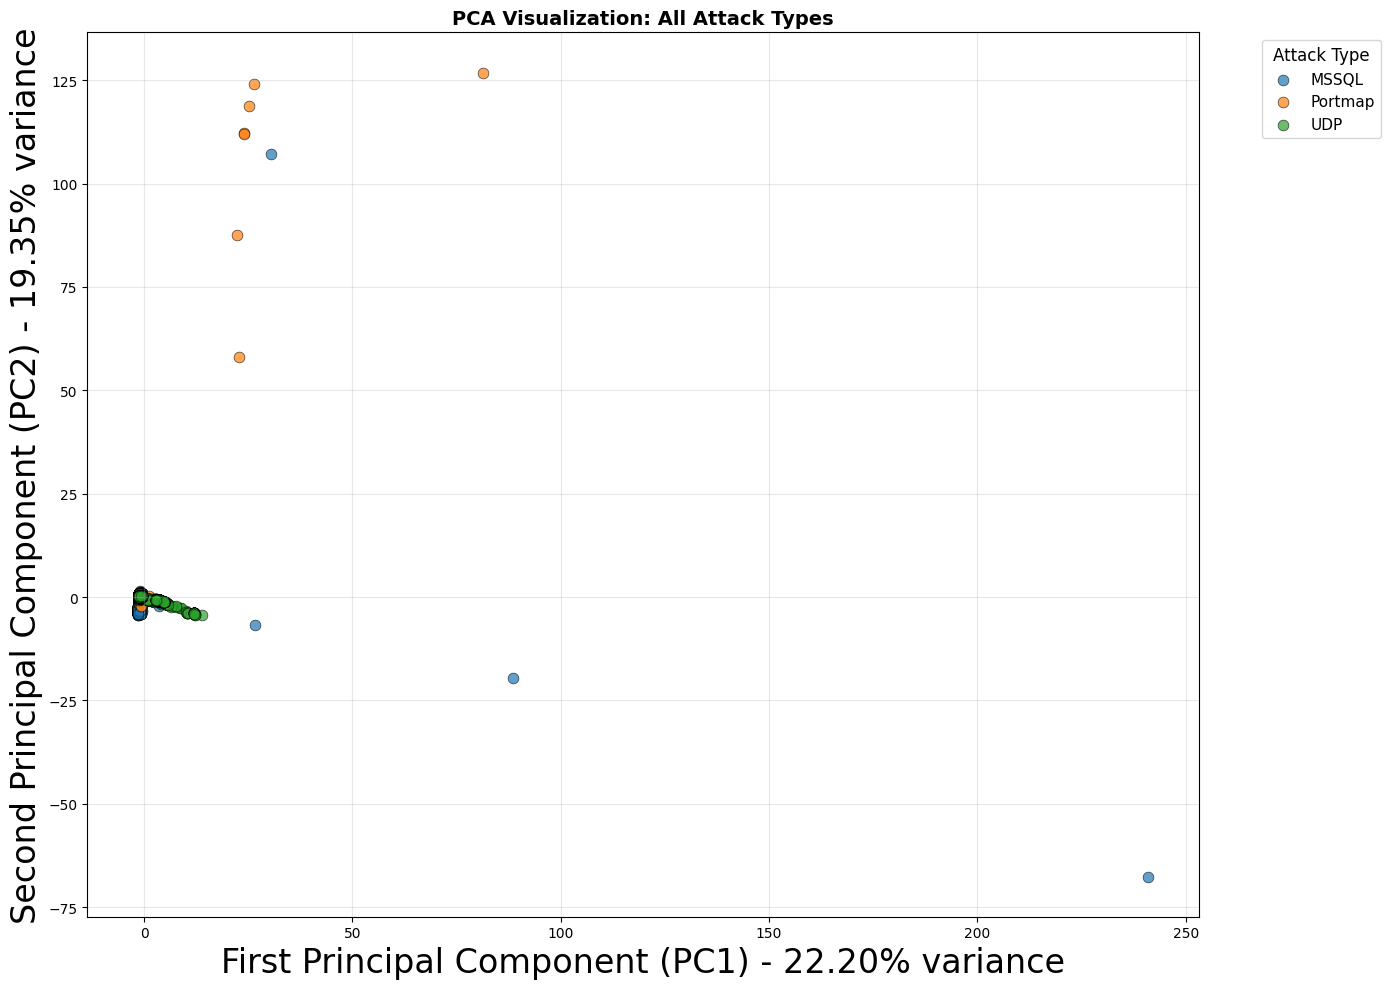


All Labels PCA Analysis (excluding UDPLag and BENIGN):
Total samples: 9250
Total variance explained by 2 components: 41.55%
PC1: 0.2220
PC2: 0.1935

Label distribution:
  MSSQL: 2803
  Portmap: 3000
  UDP: 3447


In [112]:
# Load all data for visualization of all labels (excluding UDPLag and BENIGN)
df_all = df_dropped[~df_dropped['Label'].isin(['UDPLag', 'BENIGN', 'Syn', 'LDAP', 'NetBIOS'])].copy()

# Prepare feature matrix and labels for all data
feature_cols_all = [col for col in df_all.columns if col not in ['Label', 'task_id']]
X_all = df_all[feature_cols_all].values
y_all = df_all['Label'].values

# Handle missing values
X_all = np.nan_to_num(X_all, nan=0.0)

# Standardize and apply PCA
scaler_all = StandardScaler()
X_scaled_all = scaler_all.fit_transform(X_all)

pca_all = PCA(n_components=2)
X_pca_all = pca_all.fit_transform(X_scaled_all)

# Create a scatter plot of all labels
fig_all, ax_all = plt.subplots(figsize=(14, 10))

# Use matplotlib's default colormap for better distinguishability
labels_all_unique = np.unique(y_all)
cmap = plt.cm.tab10  # Use tab10 colormap with distinct colors
n_labels = len(labels_all_unique)

# Plot each label with a different color from the colormap
for idx, label in enumerate(labels_all_unique):
    mask = y_all == label
    color = cmap(idx % 10)  # Use tab10 colors (up to 10 distinct colors)
    ax_all.scatter(X_pca_all[mask, 0], X_pca_all[mask, 1], 
                   label=label, alpha=0.7, s=60, color=color, 
                   edgecolors='black', linewidth=0.5)

ax_all.set_xlabel(f'First Principal Component (PC1) - {pca_all.explained_variance_ratio_[0]:.2%} variance', fontsize=24)
ax_all.set_ylabel(f'Second Principal Component (PC2) - {pca_all.explained_variance_ratio_[1]:.2%} variance', fontsize=24)
ax_all.set_title('PCA Visualization: All Attack Types', fontsize=14, fontweight='bold')
ax_all.legend(title='Attack Type', fontsize=11, title_fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')
ax_all.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nAll Labels PCA Analysis (excluding UDPLag and BENIGN):")
print(f"Total samples: {len(X_pca_all)}")
print(f"Total variance explained by 2 components: {np.sum(pca_all.explained_variance_ratio_):.2%}")
print(f"PC1: {pca_all.explained_variance_ratio_[0]:.4f}")
print(f"PC2: {pca_all.explained_variance_ratio_[1]:.4f}")
print(f"\nLabel distribution:")
unique, counts = np.unique(y_all, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  {label}: {count}")

In [113]:
# Analyze and compare the distributions
print("=" * 60)
print("DISTRIBUTION ANALYSIS")
print("=" * 60)

# Create a DataFrame with PCA results for easier analysis
df_pca = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Label': y
})

# Summary statistics for each label
for label in labels_unique:
    subset = df_pca[df_pca['Label'] == label]
    print(f"\n{label} Statistics:")
    print(f"  Count: {len(subset)}")
    print(f"  PC1 - Mean: {subset['PC1'].mean():.4f}, Std: {subset['PC1'].std():.4f}")
    print(f"  PC2 - Mean: {subset['PC2'].mean():.4f}, Std: {subset['PC2'].std():.4f}")
    print(f"  PC1 Range: [{subset['PC1'].min():.4f}, {subset['PC1'].max():.4f}]")
    print(f"  PC2 Range: [{subset['PC2'].min():.4f}, {subset['PC2'].max():.4f}]")

# Calculate separability metric (distance between cluster centers)
print(f"\n{'-' * 60}")
print("CLUSTER SEPARABILITY")
print(f"{'-' * 60}")

if len(labels_unique) == 2:
    subset1 = df_pca[df_pca['Label'] == labels_unique[0]]
    subset2 = df_pca[df_pca['Label'] == labels_unique[1]]
    
    center1 = np.array([subset1['PC1'].mean(), subset1['PC2'].mean()])
    center2 = np.array([subset2['PC1'].mean(), subset2['PC2'].mean()])
    
    distance = np.linalg.norm(center1 - center2)
    print(f"Distance between {labels_unique[0]} and {labels_unique[1]} centers: {distance:.4f}")
    
    # Intra-cluster distances (average distance of points to their cluster center)
    dist1 = np.mean(np.linalg.norm(subset1[['PC1', 'PC2']].values - center1, axis=1))
    dist2 = np.mean(np.linalg.norm(subset2[['PC1', 'PC2']].values - center2, axis=1))
    
    print(f"Average intra-cluster distance for {labels_unique[0]}: {dist1:.4f}")
    print(f"Average intra-cluster distance for {labels_unique[1]}: {dist2:.4f}")

print(f"\n{'-' * 60}")
print(f"Variance Explained Summary:")
print(f"PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"Total: {np.sum(pca.explained_variance_ratio_):.4f}")
print(f"{'-' * 60}")

DISTRIBUTION ANALYSIS

MSSQL Statistics:
  Count: 2803
  PC1 - Mean: -0.9102, Std: 4.9445
  PC2 - Mean: -0.5355, Std: 2.5710
  PC1 Range: [-1.4661, 240.9589]
  PC2 Range: [-67.5787, 107.2127]

Portmap Statistics:
  Count: 3000
  PC1 - Mean: -0.9082, Std: 1.8868
  PC2 - Mean: 1.0069, Std: 5.1820
  PC1 Range: [-1.1893, 81.2741]
  PC2 Range: [-2.1777, 126.8438]

UDP Statistics:
  Count: 3447
  PC1 - Mean: 1.5306, Std: 2.9059
  PC2 - Mean: -0.4409, Std: 0.7650
  PC1 Range: [-1.2085, 13.8361]
  PC2 Range: [-4.2975, 0.5452]

------------------------------------------------------------
CLUSTER SEPARABILITY
------------------------------------------------------------

------------------------------------------------------------
Variance Explained Summary:
PC1: 0.2220
PC2: 0.1935
Total: 0.4155
------------------------------------------------------------
